# Selección Empírica de Backbones para Transfer Learning


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/04_deep_learning/casos_estudio/benchmarking_backbones_transfer_learning.ipynb)

## Objetivos y Restricciones


**Objetivo principal:** Seleccionar el backbone que extraiga las mejores características visuales (features) para nuestro dominio específico, minimizando el tiempo de *Fine-Tuning* posterior.

**Restricciones de Despliegue (Edge Computing en Drones):**
- **Latencia P95:** < 60 ms por imagen (para procesar video en tiempo real).
- **Huella de Memoria (VRAM):** < 150 MB.
- **Eficiencia de Datos:** El modelo debe generalizar bien con menos de 1000 imágenes.


## Prerrequisitos

- Haber completado el Capítulo 4 (Deep Learning), especialmente [Transfer Learning y Fine-Tuning](../12_transfer_learning_y_fine_tuning.ipynb)


## Contexto del Problema


Una cooperativa agrícola necesita desplegar un modelo de Visión por Computadora en drones de bajo costo para detectar enfermedades en hojas de té en tiempo real. El equipo de Data Science ha recopilado un dataset pequeño (`~800` imágenes).

Sabemos que debemos usar **Transfer Learning**, pero el catálogo de Keras tiene más de 40 modelos pre-entrenados. El error clásico del desarrollador Junior es elegir `ResNet50` o `VGG16` por costumbre, asumiendo que el rendimiento en ImageNet se transferirá mágicamente a las hojas de té.

En este caso de estudio, construimos un **Framework de Benchmarking Empírico** para evaluar múltiples arquitecturas *antes* de gastar un solo dólar en entrenamiento profundo.

## Qué mide este framework y qué no



Este framework mide **la utilidad de los features pre-entrenados** en un dominio específico, bajo las siguientes condiciones:

- Sin fine-tuning del backbone (backbone congelado en todos los experimentos)
- Con los mismos datos, splits y condiciones para todos los candidatos
- Desde múltiples ángulos: hardware, calidad de features, separabilidad lineal, geometría

Lo que **no** mide ni pretende:
- El rendimiento final después de fine-tuning exhaustivo
- Qué backbone llegaría más lejos con un dataset de 100K imágenes
- Consideraciones de licenciamiento o costos de API

La hipótesis central del framework es: **el backbone cuyos features son más útiles en modo congelado es el mejor candidato para fine-tuning posterior**, especialmente con datos escasos.


---


## Configuración del Entorno y Datos


In [ ]:
# @title *Esta celda clona el repositorio, descarga los datos e importa utilidades*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")

    # Descarga del dataset de Enfermedades del Té (si no existe)
    if not os.path.exists("tea_sickness_dataset"):
        import gdown
        gdown.download(f"https://drive.google.com/uc?id=1ac6EkoBBxCEnJNcJO438DGHhGQKaTELx", "tea_sickness_dataset.zip", quiet=False)
        subprocess.run(["unzip", "-qq", "tea_sickness_dataset.zip"], check=True)
        os.remove("tea_sickness_dataset.zip")
else:
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import gc
from pathlib import Path
import itertools

# Herramientas de evaluación clásica
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, silhouette_score
from sklearn.model_selection import train_test_split

keras.utils.set_random_seed(42)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f"GPU detectada: {gpus[0].name}")
else:
    print("ADVERTENCIA: Sin GPU. Las etapas de inferencia serán MUY LENTAS. Los benchmarks de latencia se realizan exclusivamente sobre GPU.")

Downloading...
From (original): https://drive.google.com/uc?id=1ac6EkoBBxCEnJNcJO438DGHhGQKaTELx
From (redirected): https://drive.google.com/uc?id=1ac6EkoBBxCEnJNcJO438DGHhGQKaTELx&confirm=t&uuid=fa04a907-115b-4943-92fe-b9ccd35f3ceb
To: /content/applied-ai-engineering/tea_sickness_dataset.zip
100%|██████████| 775M/775M [00:08<00:00, 93.1MB/s]


GPU detectada: /physical_device:GPU:0


### Preparación del Dataset



Reutilizamos la lógica de división estricta para evitar *Data Leakage*.

In [2]:
# 1. Mapeo de rutas y etiquetas
DATA_DIR = Path('./tea_sickness_dataset')
classes = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
n_classes = len(classes)
cls2idx = {c: i for i, c in enumerate(classes)}

all_paths, all_labels = [], []
for cls_name in classes:
    paths = list((DATA_DIR / cls_name).glob("*.*"))
    paths = [p for p in paths if p.suffix.lower() in ['.jpg','.jpeg','.png']]
    all_paths.extend([str(p) for p in paths])
    all_labels.extend([cls2idx[cls_name]] * len(paths))

all_paths = np.array(all_paths)
all_labels = np.array(all_labels)

# 2. Split Estratificado (70% Train, 15% Val, 15% Test)
idx = np.arange(len(all_paths))
idx_tv, idx_test = train_test_split(idx, test_size=0.15, stratify=all_labels, random_state=42)
idx_train, idx_val = train_test_split(idx_tv, test_size=0.15/0.85, stratify=all_labels[idx_tv], random_state=42)

splits = {
    "train": (all_paths[idx_train], all_labels[idx_train]),
    "val":   (all_paths[idx_val],   all_labels[idx_val]),
    "test":  (all_paths[idx_test],  all_labels[idx_test]),
}

print(f"Dataset: {len(all_paths)} imágenes - {n_classes} clases")
print(f"Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}")


Dataset: 885 imágenes - 8 clases
Train: 619 | Val: 133 | Test: 133


## Exploración de Modelos (*Model Exploration*)


Definimos nuestro registro de candidatos. No probamos los 40 modelos de Keras, sino una selección estratégica que cubra diferentes familias arquitectónicas y tamaños.

In [3]:
# Registro de Backbones a evaluar
BACKBONE_REGISTRY = {
    "MobileNetV3Small": {
        "constructor": keras.applications.MobileNetV3Small,
        "preprocess": keras.applications.mobilenet_v3.preprocess_input,
        "input_size": 224, "params_M": 0.94, "family": "MobileNet"
    },
    "EfficientNetB0": {
        "constructor": keras.applications.EfficientNetB0,
        "preprocess": keras.applications.efficientnet.preprocess_input,
        "input_size": 224, "params_M": 4.05, "family": "EfficientNet"
    },
    "ResNet50V2": {
        "constructor": keras.applications.ResNet50V2,
        "preprocess": keras.applications.resnet_v2.preprocess_input,
        "input_size": 224, "params_M": 23.56, "family": "ResNet"
    },
    "DenseNet121": {
        "constructor": keras.applications.DenseNet121,
        "preprocess": keras.applications.densenet.preprocess_input,
        "input_size": 224, "params_M": 7.04, "family": "DenseNet"
    },
    "ConvNeXtTiny": {
        "constructor": keras.applications.ConvNeXtTiny,
        "preprocess": keras.applications.convnext.preprocess_input,
        "input_size": 224, "params_M": 27.82, "family": "ConvNeXt"
    }
}

CANDIDATES = list(BACKBONE_REGISTRY.keys())
print(f"Evaluando {len(CANDIDATES)} familias arquitectónicas distintas.")

Evaluando 5 familias arquitectónicas distintas.


## *Trade-offs* de Modelos: Los 4 Ejes de Evaluación


La arquitectura de nuestro framework evaluará los modelos en 4 dimensiones críticas. Extraemos las características (*features*) de las imágenes **una sola vez por modelo** pasándolas por la red congelada. Esto nos ahorrará horas de cómputo.


> **¿Por qué necesitamos múltiples ejes?**  
> Ninguna métrica única captura todo lo que importa. Dependiendo del contexto de despliegue, el peso de cada dimensión cambia:

> | Dimensión | Relevante cuando... |
> |-----------|-------------------|
> | Latencia | Deploy en edge, tiempo real, API con SLA |
> | Throughput | Procesamiento batch de imágenes en producción |
> | Huella de memoria | GPU compartida, múltiples modelos en paralelo |
> | Calidad kNN | Dataset muy pequeño, pocos datos etiquetados |
> | Sonda lineal | Evaluación rápida de separabilidad |
> | Geometría latente | Interpretabilidad, clustering, detección de anomalías |

Medimos desempeño sobre 4 ejes para ejemplificar:

### Eje 1: Benchmark de Hardware (Latencia y Memoria)



> **Criterio de Ingeniería:** ¿Por qué medimos la latencia **P95** (Percentil 95) en lugar del promedio? En sistemas de tiempo real (como un dron volando), si el promedio es 20ms pero el 5% de los frames tardan 500ms, el dron se estrellará. El P95 garantiza que el 95% de las inferencias cumplirán con nuestro SLA (Service Level Agreement).



In [4]:
def benchmark_hardware(name, n_warmup=5, n_measure=30):
    cfg = BACKBONE_REGISTRY[name]
    img_size = cfg["input_size"]

    # Instanciamos el modelo sin la cabeza clasificadora
    backbone = cfg["constructor"](include_top=False, weights="imagenet", pooling="avg", input_shape=(img_size, img_size, 3))
    backbone.trainable = False

    dummy_single = tf.random.normal((1, img_size, img_size, 3))

    # Warm-up (Calentamiento de la GPU)
    for _ in range(n_warmup):
        _ = backbone(dummy_single, training=False)

    # Medición de Latencia
    latencies = []
    for _ in range(n_measure):
        t0 = time.perf_counter()
        _ = backbone(dummy_single, training=False)
        latencies.append((time.perf_counter() - t0) * 1000)

    # Memoria Pico (Solo válido si hay GPU)
    peak_mb = tf.config.experimental.get_memory_info('GPU:0')['peak'] / (1024**2) if gpus else 0.0

    feat_dim = backbone(dummy_single, training=False).shape[-1]

    del backbone
    gc.collect()
    tf.keras.backend.clear_session()

    return {
        "latency_p50_ms": np.percentile(latencies, 50),
        "latency_p95_ms": np.percentile(latencies, 95),
        "gpu_peak_mb": peak_mb,
        "feat_dim": int(feat_dim)
    }

print("--- EJE 1: Benchmark de Hardware ---")
hw_results = {}
for name in CANDIDATES:
    r = benchmark_hardware(name)
    hw_results[name] = r
    print(f"{name:<18} | P95: {r['latency_p95_ms']:>5.1f} ms | VRAM: {r['gpu_peak_mb']:>5.0f} MB | Params: {BACKBONE_REGISTRY[name]['params_M']}M")

--- EJE 1: Benchmark de Hardware ---
4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV3Small   | P95: 234.5 ms | VRAM:    72 MB | Params: 0.94M
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0     | P95: 407.3 ms | VRAM:   116 MB | Params: 4.05M
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50V2         | P95: 314.6 ms | VRAM:  1353 MB | Params: 23.56M
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
DenseNet121        | P95: 600.2 ms | VRAM:  1353 MB | Params: 7.04M
111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


ConvNeXtTiny       | P95: 3319.0 ms | VRAM:  1483 MB | Params: 27.82M


### Extracción de Features (El Motor del Framework)



Para los siguientes ejes, necesitamos extraer los vectores matemáticos que cada red produce para nuestras imágenes.



In [5]:
def extract_features(name, paths, batch_size=32):
    cfg = BACKBONE_REGISTRY[name]
    img_size = cfg["input_size"]
    preprocess_fn = cfg["preprocess"]

    backbone = cfg["constructor"](include_top=False, weights="imagenet", pooling="avg", input_shape=(img_size, img_size, 3))
    backbone.trainable = False

    all_features = []
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i+batch_size]
        imgs = []
        for p in batch_paths:
            img = tf.io.read_file(p)
            img = tf.image.decode_image(img, channels=3, expand_animations=False)
            img = tf.image.resize(img, [img_size, img_size])
            imgs.append(preprocess_fn(tf.cast(img, tf.float32)))

        feats = backbone(tf.stack(imgs), training=False).numpy()
        all_features.append(feats)

    del backbone
    gc.collect()
    tf.keras.backend.clear_session()
    return np.concatenate(all_features, axis=0)

print("\nExtrayendo features (esto tomará un par de minutos)...")
feature_store = {}
for name in CANDIDATES:
    print(f"Procesando {name}...")
    feature_store[name] = {
        "train": extract_features(name, splits["train"][0]),
        "val":   extract_features(name, splits["val"][0]),
        "test":  extract_features(name, splits["test"][0])
    }


Extrayendo features (esto tomará un par de minutos)...
Procesando MobileNetV3Small...
Procesando EfficientNetB0...
Procesando ResNet50V2...
Procesando DenseNet121...
Procesando ConvNeXtTiny...


### Eje 2: Calidad de Features (kNN y Silhouette)



Si un backbone es bueno para nuestro dominio, las imágenes de la misma enfermedad deberían agruparse naturalmente en el espacio matemático, **incluso antes de entrenar**. Medimos esto con un clasificador kNN (que no tiene pesos entrenables) y el *Silhouette Score*.



In [6]:
print("--- EJE 2: Calidad Intrínseca de Features ---")
knn_results = {}
sil_results = {}

for name in CANDIDATES:
    X_train_feat = feature_store[name]["train"]
    X_test_feat = feature_store[name]["test"]

    # Normalización
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_feat)
    X_test_s = scaler.transform(X_test_feat)

    # 1. kNN Accuracy
    knn = KNeighborsClassifier(n_neighbors=5, metric='cosine')
    knn.fit(X_train_s, splits["train"][1])
    acc = accuracy_score(splits["test"][1], knn.predict(X_test_s))
    knn_results[name] = acc

    # 2. Silhouette Score (Cohesión de clusters)
    # Usamos PCA previo para evitar la maldición de la dimensionalidad
    X_pca = PCA(n_components=min(50, X_train_s.shape[1])).fit_transform(X_train_s)
    sil = silhouette_score(X_pca, splits["train"][1], metric='cosine')
    sil_results[name] = sil

    print(f"{name:<18} | kNN Acc: {acc*100:>5.1f}% | Silhouette: {sil:>6.3f}")

--- EJE 2: Calidad Intrínseca de Features ---
MobileNetV3Small   | kNN Acc:  77.4% | Silhouette:  0.088
EfficientNetB0     | kNN Acc:  76.7% | Silhouette:  0.075
ResNet50V2         | kNN Acc:  70.7% | Silhouette:  0.025
DenseNet121        | kNN Acc:  82.7% | Silhouette:  0.120
ConvNeXtTiny       | kNN Acc:  74.4% | Silhouette:  0.073


### Eje 3: Benchmark Supervisado (Sonda Lineal)



> **Criterio de Ingeniería:** La **Sonda Lineal** (*Linear Probe*) es el estándar de oro en la investigación de IA. Consiste en entrenar una simple Regresión Logística sobre los features congelados. Si la Sonda Lineal da un 90%, significa que las clases ya son linealmente separables; un *Fine-Tuning* ligero bastará. Si da un 40%, el backbone no entendió el dominio.



In [ ]:
print("\n--- EJE 3: Sonda Lineal (Proxy de Fine-Tuning) ---")
linear_results = {}

for name in CANDIDATES:
    X_train_s = StandardScaler().fit_transform(feature_store[name]["train"])
    X_test_s = StandardScaler().fit_transform(feature_store[name]["test"])

    clf = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    clf.fit(X_train_s, splits["train"][1])
    acc = accuracy_score(splits["test"][1], clf.predict(X_test_s))
    linear_results[name] = acc

    print(f"{name:<18} | Linear Probe Acc: {acc*100:>5.1f}%")


--- EJE 3: Sonda Lineal (Proxy de Fine-Tuning) ---
MobileNetV3Small   | Linear Probe Acc:  88.7%
EfficientNetB0     | Linear Probe Acc:  86.5%
ResNet50V2         | Linear Probe Acc:  81.2%
DenseNet121        | Linear Probe Acc:  94.7%
ConvNeXtTiny       | Linear Probe Acc:  90.2%


### Eje 4: Geometría del Espacio Latente (t-SNE)


Visualizamos cómo cada backbone "ve" nuestras hojas de té. Un buen backbone mostrará islas separadas por colores.

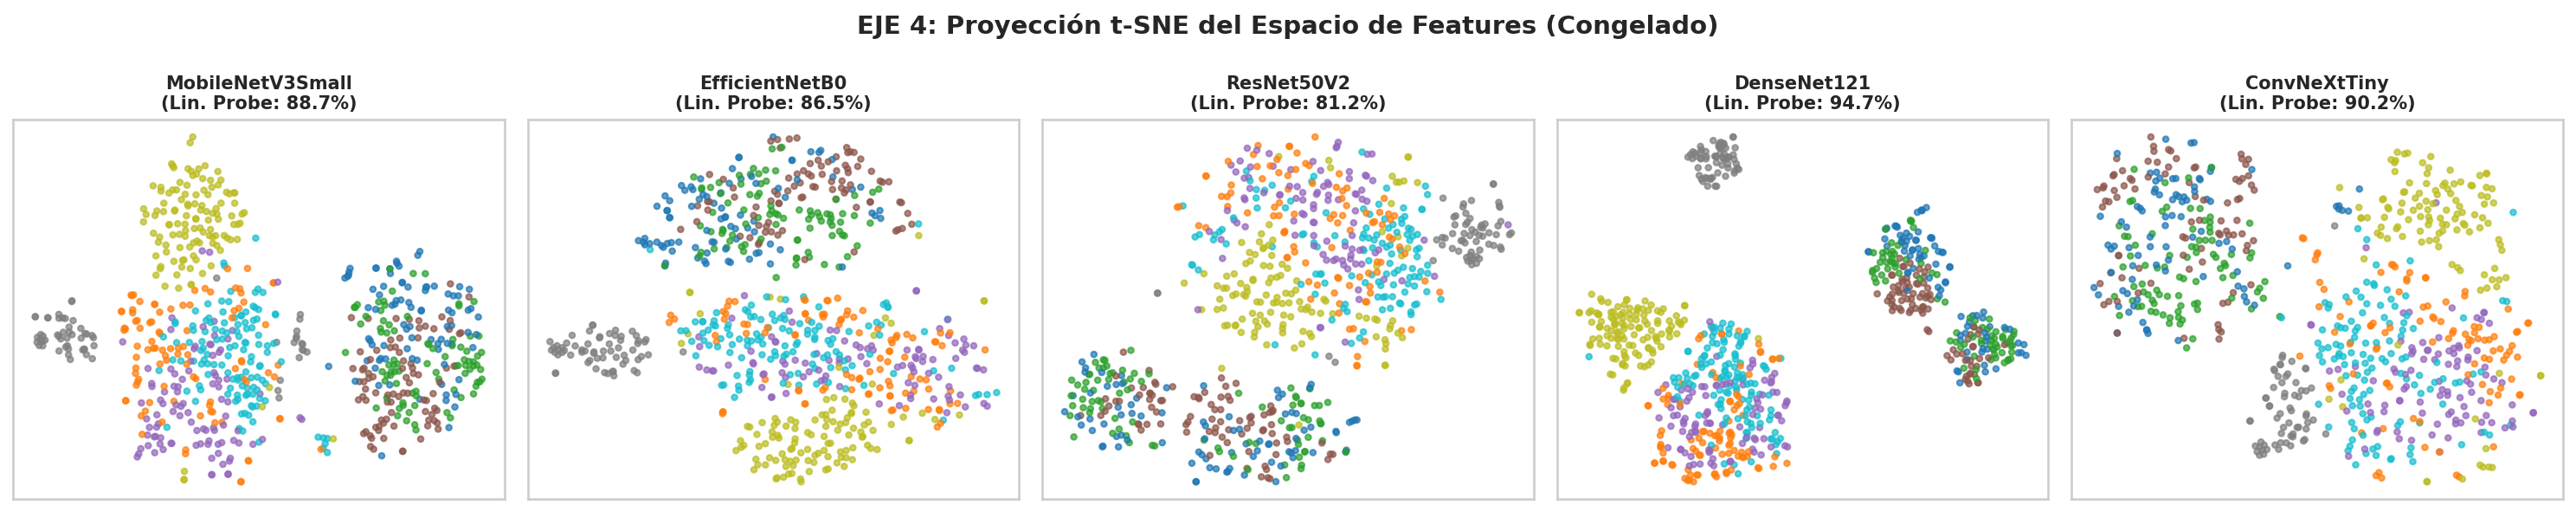

In [8]:
fig, axes = plt.subplots(1, len(CANDIDATES), figsize=(20, 4))
fig.suptitle('EJE 4: Proyección t-SNE del Espacio de Features (Congelado)', fontsize=14, fontweight='bold')

for ax, name in zip(axes, CANDIDATES):
    X_all = np.concatenate([feature_store[name]["train"], feature_store[name]["test"]])
    y_all = np.concatenate([splits["train"][1], splits["test"][1]])

    # Reducción a 2D
    X_pca = PCA(n_components=50).fit_transform(StandardScaler().fit_transform(X_all))
    X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_pca)

    scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_all, cmap='tab10', s=10, alpha=0.7)
    ax.set_title(f"{name}\n(Lin. Probe: {linear_results[name]*100:.1f}%)", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

## Selección del Modelo: Motor de Decisión Multi-Criterio


No elegimos el modelo solo por su *Accuracy*. Construimos un *score* compuesto ponderando nuestras restricciones de negocio.

In [9]:
# Pesos de Decisión (Ajustados para Edge Computing en Drones)
# Esta es una ponderación totalmente arbitraria, con fines demostrativos solamente
DECISION_WEIGHTS = {
    "linear_probe_acc": 0.40,  # Queremos alta precisión
    "latency_p95_ms":   0.30,  # La velocidad es crítica para el dron
    "params_M":         0.20,  # Modelos pequeños consumen menos batería
    "silhouette":       0.10   # Bonus por buena estructura latente
}

def norm_higher_better(val, arr): return (val - min(arr)) / (max(arr) - min(arr) + 1e-8)
def norm_lower_better(val, arr): return 1.0 - norm_higher_better(val, arr)

# Recopilamos arrays para normalizar
arr_lin = [linear_results[n] for n in CANDIDATES]
arr_lat = [hw_results[n]["latency_p95_ms"] for n in CANDIDATES]
arr_par = [BACKBONE_REGISTRY[n]["params_M"] for n in CANDIDATES]
arr_sil = [sil_results[n] for n in CANDIDATES]

scores = {}
for n in CANDIDATES:
    s_lin = norm_higher_better(linear_results[n], arr_lin)
    s_lat = norm_lower_better(hw_results[n]["latency_p95_ms"], arr_lat)
    s_par = norm_lower_better(BACKBONE_REGISTRY[n]["params_M"], arr_par)
    s_sil = norm_higher_better(sil_results[n], arr_sil)

    score_final = (s_lin * DECISION_WEIGHTS["linear_probe_acc"] +
                   s_lat * DECISION_WEIGHTS["latency_p95_ms"] +
                   s_par * DECISION_WEIGHTS["params_M"] +
                   s_sil * DECISION_WEIGHTS["silhouette"]) * 100
    scores[n] = score_final

# Ordenamos el ranking
ranking = sorted(scores.items(), key=lambda x: x[1], reverse=True)

print(" ---RANKING FINAL MULTI-CRITERIO--- ")
print("-" * 60)
print(f"{'Backbone':<18} | {'Score Final':<12} | {'Lin. Acc':<10} | {'Latencia P95'}")
print("-" * 60)
for name, score in ranking:
    print(f"{name:<18} | {score:>6.1f} / 100 | {linear_results[name]*100:>5.1f}%    | {hw_results[name]['latency_p95_ms']:>5.1f} ms")


 ---RANKING FINAL MULTI-CRITERIO--- 
------------------------------------------------------------
Backbone           | Score Final  | Lin. Acc   | Latencia P95
------------------------------------------------------------
DenseNet121        |   91.9 / 100 |  94.7%    | 600.2 ms
MobileNetV3Small   |   78.8 / 100 |  88.7%    | 234.5 ms
EfficientNetB0     |   66.9 / 100 |  86.5%    | 407.3 ms
ResNet50V2         |   32.4 / 100 |  81.2%    | 314.6 ms
ConvNeXtTiny       |   31.7 / 100 |  90.2%    | 3319.0 ms


## Lecciones de Ingeniería y Conclusión



Al observar el ranking final, la lección es clara:
1. **El modelo más grande no siempre gana:** `ConvNeXtTiny` puede tener una precisión superior en la Sonda Lineal (top 2 para este caso), pero su latencia y tamaño los penalizan severamente en nuestro contexto de *Edge Computing*.
2. **El ganador contextual:** `DenseNet121` fue el ganador aquí, todo depende de la asignación de pesos según las necesidades. Sino `EfficientNetB0` o `MobileNetV3Small` suelen coronarse en este tipo de benchmarks porque ofrecen un 95% del rendimiento de los modelos gigantes, costando una fracción del cómputo.
3. **Ahorro de Recursos:** Ejecutar este script tomó unos pocos minutos. Si hubiéramos intentado hacer *Fine-Tuning* profundo de los 5 modelos para ver cuál era mejor, habríamos gastado horas de GPU y cientos de dólares en la nube.



Si somos estrictos con la latencia requerida inicialmente (`< 60 ms` por imagen, para procesar video en tiempo real), observar que ningún modelo lo está cumpliendo en su estado actual (el tiempo no incluye la cabeza de clasificación todavía). Por lo tanto, esto implica sacrificar la tasa de fotogramas por segundo, ó, tomar el modelo y optimizarlo para su ejecución en hardware del edge. Por cualquiera de los caminos, conviene recorrerlo con un modelo acorde y cercano a los requerimientos que buscamos.

> **Nota de diseño:** Este framework está construido sobre una premisa fundamental que separa el pensamiento de senior del de junior: **no hay un backbone universalmente mejor**. Hay backbones más o menos alineados con un dominio específico, bajo unas restricciones de hardware específicas, con un volumen de datos específico. El valor del framework no está en el ranking que produce, más bien está en obligarte a medir todas las dimensiones relevantes antes de comprometer semanas de cómputo en fine-tuning del candidato incorrecto. En proyectos reales, el backbone equivocado cuesta tiempo, dinero y credibilidad. Un benchmark de 2 horas antes de decidir es siempre la inversión más rentable del proyecto.

## Trabajo Futuro


- **Integración con HuggingFace:** Este framework puede expandirse fácilmente para evaluar modelos de la librería `transformers` (ej. Vision Transformers - ViT), simplemente cambiando la función de extracción.
- **Evaluación de Robustez (Domain Shift):** Podríamos inyectar ruido o desenfoque a las imágenes de prueba para ver qué backbone mantiene mejor sus características bajo condiciones climáticas adversas en el campo.
- **Cuantización y/o poda:** Optimizar el modelo (incluyendo cabeza de clasificación y *fine tuning*), para su ejecución en hardware del edge. Apuntando a lograr la latencia requerida inicialmente (`< 60 ms` por imagen). *PROXIMAMENTE NOTEBOOK...*

---


## Entorno de Ejecución


In [11]:
from utils.environment import environment_table
environment_table(include_all=True)

Package,Version
Python,3.12.13
Platform,Linux-6.6.122+-x86_64-with-glibc2.35
Cython,3.0.12
IPython,7.34.0
OpenSSL,24.2.1
PIL,11.3.0
anywidget,0.9.21
argparse,1.1
astunparse,1.6.3
attr,26.1.0
